#Downloads and imports (~30s)

In [ ]:
# download TA-Lib
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
#!ls
!tar xvzf ta-lib-0.4.0-src.tar.gz
#!ls
import os
os.chdir('ta-lib') # Can't use !cd in co-lab
!./configure --prefix=/usr
!make
!make install
# wait ~ 30s
os.chdir('../')
#!ls
!pip install TA-Lib

--2026-02-20 02:39:00--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:c95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.12.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2026-02-20 02:39:00--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://pilotfiber.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2026-02-20 02:39:00--  http://pilotfiber.dl.

In [ ]:
#!pip install yfinance

In [ ]:
import talib as ta
import random
import time
import datetime as dt
from datetime import datetime, timedelta
import numpy as np
import yfinance as yf
import pandas as pd
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning) #ignores "Dataframe is highly fragmented" warning.
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier,
                              StackingClassifier, HistGradientBoostingClassifier,
                              ExtraTreesClassifier, BaggingClassifier, VotingClassifier)
from sklearn.neural_network import MLPClassifier
from matplotlib import pyplot as plt
import math
import lightgbm as lgb
from dateutil.relativedelta import relativedelta

#Functions (~10s)


In [ ]:
def change_days(date_str, days):
    import datetime as dt
    date = dt.datetime.strptime(date_str, "%Y-%m-%d")

    new_date = date + timedelta(days=days)

    return new_date.strftime("%Y-%m-%d")

def change_months(date_str, monthss):
  import datetime as dt
  date_obj = datetime.strptime(date_str, "%Y-%m-%d")

  new_date = date_obj + relativedelta(months=monthss)

  return new_date.strftime("%Y-%m-%d")

def data(stock, startdate, enddate, shuffle=True):

  #push end date back a month to increase viable data(non-NaN) to right before dates tested
  enddate = enddate

  stock_data = yf.Ticker(stock).history(start = startdate, end=enddate)

  #Closing prices on previous days:
  for i in range(1,60):
          stock_data[f"Close -{i}d"] = stock_data["Close"].shift(i)
          stock_data[f"High -{i}d"] = stock_data["High"].shift(i)
          stock_data[f"Low -{i}d"] = stock_data["Low"].shift(i)


  #Technical indicators
  stock_data['BB_upper'], stock_data['BB_middle'], stock_data['BB_lower'] = ta.BBANDS(stock_data['Close'], timeperiod=20, nbdevup=0, nbdevdn=2, matype=0)
  stock_data['KAMA'] = ta.KAMA(stock_data['Close'], timeperiod=30)
  stock_data['MA'] = ta.MA(stock_data['Close'], timeperiod=30)
  stock_data['TRIMA'] = ta.TRIMA(stock_data['Close'], timeperiod=30)
  stock_data['ADXR'] = ta.ADXR(stock_data['High'], stock_data['Low'], stock_data['Close'], timeperiod=14)
  stock_data['APO'] = ta.APO(stock_data['Close'], fastperiod=12, slowperiod=26)
  stock_data['MINUS_DI'] = ta.MINUS_DI(stock_data['High'], stock_data['Low'], stock_data['Close'], timeperiod=14)
  stock_data['MINUS_DM'] = ta.MINUS_DM(stock_data['High'], stock_data['Low'], timeperiod=14)
  stock_data['PPO'] = ta.PPO(stock_data['Close'], fastperiod=12, slowperiod=26, matype=0)
  stock_data['ADOSC'] = ta.ADOSC(stock_data['High'], stock_data['Low'], stock_data['Close'], stock_data['Volume'], fastperiod=3, slowperiod=10)
  stock_data['HT_DCPERIOD'] = ta.HT_DCPERIOD(stock_data['Close'])
  stock_data['TYPPRICE'] = ta.TYPPRICE(stock_data['High'], stock_data['Low'], stock_data['Close'])
  stock_data['WCLPRICE'] = ta.WCLPRICE(stock_data['High'], stock_data['Low'], stock_data['Close'])
  stock_data['DEMA'] = ta.DEMA(stock_data['Close'], timeperiod=30)##
  stock_data["EMA"] = ta.EMA(stock_data["Close"], timeperiod=14)  ##
  stock_data['HT_TRENDLINE'] = ta.HT_TRENDLINE(stock_data['Close'])##
  stock_data['MIDPOINT'] = ta.MIDPOINT(stock_data['Close'], timeperiod=14)##
  stock_data['ADX'] = ta.ADX(stock_data["High"], stock_data["Low"], stock_data["Close"], timeperiod=14)  ##
  stock_data["RSI"] = ta.RSI(stock_data["Close"], timeperiod=14)##
  stock_data["OBV"] = ta.OBV(stock_data["Close"], stock_data["Volume"])##
  stock_data["MIDPOINT_30"] = stock_data["MIDPOINT"].pct_change(periods=30)
  stock_data['SAR'] = ta.SAR(stock_data['High'], stock_data['Low'], acceleration=0.02, maximum=0.2)
  stock_data['macd'], stock_data['macd_signal'], stock_data['macd_diff'] = ta.MACD(stock_data['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
  stock_data["bband_width"] = stock_data['BB_upper'] - stock_data['BB_lower']
  stock_data['stochastic oscillator %K'], stock_data['stochastic oscillator %D'] = ta.STOCH(stock_data['High'], stock_data['Low'], stock_data['Close'], fastk_period=5, slowk_period=3, slowk_matype=0, slowd_period=3, slowd_matype=0)
  stock_data["atr"] = ta.ATR(stock_data["High"], stock_data["Low"], stock_data["Close"], timeperiod=14)
  stock_data["SMA"] = ta.SMA(stock_data["Close"], timeperiod=14)
  stock_data["ROC"] = ta.ROC(stock_data["Close"], timeperiod=12)
  stock_data["CCI"] = ta.CCI(stock_data["High"], stock_data["Low"], stock_data["Close"], timeperiod=14)
  stock_data["AD"] = ta.AD(stock_data["High"], stock_data["Low"], stock_data["Close"], stock_data["Volume"])
  stock_data["NATR"] = ta.NATR(stock_data["High"], stock_data["Low"], stock_data["Close"], timeperiod=14)
  stock_data["TRIX"] = ta.TRIX(stock_data["Close"],timeperiod=30)

  #5 day
  stock_data['BB_upper_5'], stock_data['BB_middle_5'], stock_data['BB_lower_5'] = ta.BBANDS(stock_data['Close -5d'], timeperiod=5, nbdevup=0, nbdevdn=2, matype=0)
  stock_data["bband_width_5"] = stock_data['BB_upper_5'] - stock_data['BB_lower_5']
  stock_data['KAMA_5'] = ta.KAMA(stock_data['Close -5d'], timeperiod=5)
  stock_data['MA_5'] = ta.MA(stock_data['Close -5d'], timeperiod=5)
  stock_data['TRIMA_5'] = ta.TRIMA(stock_data['Close -5d'], timeperiod=5)
  stock_data['ADXR_5'] = ta.ADXR(stock_data['High -5d'], stock_data['Low -5d'], stock_data['Close -5d'], timeperiod=5)
  stock_data['MINUS_DI_5'] = ta.MINUS_DI(stock_data['High -5d'], stock_data['Low -5d'], stock_data['Close -5d'], timeperiod=5)
  stock_data['MINUS_DM_5'] = ta.MINUS_DM(stock_data['High -5d'], stock_data['Low -5d'], timeperiod=5)
  stock_data['DEMA_5'] = ta.DEMA(stock_data['Close -5d'], timeperiod=5)
  stock_data["EMA_5"] = ta.EMA(stock_data["Close -5d"], timeperiod=5)
  stock_data['HT_TRENDLINE_5'] = stock_data["HT_TRENDLINE"].pct_change(periods=5)
  stock_data['MIDPOINT_5'] = ta.MIDPOINT(stock_data['Close -5d'], timeperiod=5)
  stock_data['ADX_5'] = ta.ADX(stock_data["High -5d"], stock_data["Low -5d"], stock_data["Close -5d"], timeperiod=5)
  stock_data["RSI_5"] = ta.RSI(stock_data["Close -5d"], timeperiod=5)
  stock_data["MIDPOINT_30_5"] = stock_data["MIDPOINT_5"].pct_change(periods=5)
  stock_data["atr_5"] = ta.ATR(stock_data["High -5d"], stock_data["Low -5d"], stock_data["Close -5d"], timeperiod=5)
  stock_data["SMA_5"] = ta.SMA(stock_data["Close -5d"], timeperiod=5)
  stock_data["ROC_5"] = ta.ROC(stock_data["Close -5d"], timeperiod=5)
  stock_data["CCI_5"] = ta.CCI(stock_data["High -5d"], stock_data["Low -5d"], stock_data["Close -5d"], timeperiod=5)
  stock_data["NATR_5"] = ta.NATR(stock_data["High -5d"], stock_data["Low -5d"], stock_data["Close -5d"], timeperiod=5)
  stock_data["TRIX_5"] = ta.TRIX(stock_data["Close -5d"], timeperiod=5)

  #10 day
  stock_data['BB_upper_10'], stock_data['BB_middle_10'], stock_data['BB_lower_10'] = ta.BBANDS(stock_data['Close -10d'], timeperiod=5, nbdevup=0, nbdevdn=2, matype=0)
  stock_data["bband_width_10"] = stock_data['BB_upper_10'] - stock_data['BB_lower_10']
  stock_data['KAMA_10'] = ta.KAMA(stock_data['Close -10d'], timeperiod=5)
  stock_data['MA_10'] = ta.MA(stock_data['Close -10d'], timeperiod=5)
  stock_data['TRIMA_10'] = ta.TRIMA(stock_data['Close -10d'], timeperiod=5)
  stock_data['ADXR_10'] = ta.ADXR(stock_data['High -10d'], stock_data['Low -10d'], stock_data['Close -10d'], timeperiod=5)
  stock_data['MINUS_DI_10'] = ta.MINUS_DI(stock_data['High -10d'], stock_data['Low -10d'], stock_data['Close -10d'], timeperiod=5)
  stock_data['MINUS_DM_10'] = ta.MINUS_DM(stock_data['High -10d'], stock_data['Low -10d'], timeperiod=5)
  stock_data['DEMA_10'] = ta.DEMA(stock_data['Close -10d'], timeperiod=5)
  stock_data["EMA_10"] = ta.EMA(stock_data["Close -10d"], timeperiod=5)
  stock_data['HT_TRENDLINE_10'] = stock_data["HT_TRENDLINE"].pct_change(periods=5)
  stock_data['MIDPOINT_10'] = ta.MIDPOINT(stock_data['Close -10d'], timeperiod=5)
  stock_data['ADX_10'] = ta.ADX(stock_data["High -10d"], stock_data["Low -10d"], stock_data["Close -10d"], timeperiod=5)
  stock_data["RSI_10"] = ta.RSI(stock_data["Close -10d"], timeperiod=5)
  stock_data["MIDPOINT_30_10"] = stock_data["MIDPOINT_10"].pct_change(periods=5)
  stock_data["atr_10"] = ta.ATR(stock_data["High -10d"], stock_data["Low -10d"], stock_data["Close -10d"], timeperiod=5)
  stock_data["SMA_10"] = ta.SMA(stock_data["Close -10d"], timeperiod=5)
  stock_data["ROC_10"] = ta.ROC(stock_data["Close -10d"], timeperiod=5)
  stock_data["CCI_10"] = ta.CCI(stock_data["High -10d"], stock_data["Low -10d"], stock_data["Close -10d"], timeperiod=5)
  stock_data["NATR_10"] = ta.NATR(stock_data["High -10d"], stock_data["Low -10d"], stock_data["Close -10d"], timeperiod=5)
  stock_data["TRIX_10"] = ta.TRIX(stock_data["Close -10d"], timeperiod=5)

  #30 day
  stock_data['BB_upper_30'], stock_data['BB_middle_30'], stock_data['BB_lower_30'] = ta.BBANDS(stock_data['Close -30d'], timeperiod=5, nbdevup=0, nbdevdn=2, matype=0)
  stock_data["bband_width_30"] = stock_data['BB_upper_30'] - stock_data['BB_lower_30']
  stock_data['KAMA_30'] = ta.KAMA(stock_data['Close -30d'], timeperiod=5)
  stock_data['MA_30'] = ta.MA(stock_data['Close -30d'], timeperiod=5)
  stock_data['TRIMA_30'] = ta.TRIMA(stock_data['Close -30d'], timeperiod=5)
  stock_data['ADXR_30'] = ta.ADXR(stock_data['High -30d'], stock_data['Low -30d'], stock_data['Close -30d'], timeperiod=5)
  stock_data['MINUS_DI_30'] = ta.MINUS_DI(stock_data['High -30d'], stock_data['Low -30d'], stock_data['Close -30d'], timeperiod=5)
  stock_data['MINUS_DM_30'] = ta.MINUS_DM(stock_data['High -30d'], stock_data['Low -30d'], timeperiod=5)
  stock_data['DEMA_30'] = ta.DEMA(stock_data['Close -30d'], timeperiod=5)
  stock_data["EMA_30"] = ta.EMA(stock_data["Close -30d"], timeperiod=5)
  stock_data['HT_TRENDLINE_30'] = stock_data["HT_TRENDLINE"].pct_change(periods=5)
  stock_data['MIDPOINT_30'] = ta.MIDPOINT(stock_data['Close -30d'], timeperiod=5)
  stock_data['ADX_30'] = ta.ADX(stock_data["High -30d"], stock_data["Low -30d"], stock_data["Close -30d"], timeperiod=5)
  stock_data["RSI_30"] = ta.RSI(stock_data["Close -30d"], timeperiod=5)
  stock_data["MIDPOINT_30_30"] = stock_data["MIDPOINT_30"].pct_change(periods=5)
  stock_data["atr_30"] = ta.ATR(stock_data["High -30d"], stock_data["Low -30d"], stock_data["Close -30d"], timeperiod=5)
  stock_data["SMA_30"] = ta.SMA(stock_data["Close -30d"], timeperiod=5)
  stock_data["ROC_30"] = ta.ROC(stock_data["Close -30d"], timeperiod=5)
  stock_data["CCI_30"] = ta.CCI(stock_data["High -30d"], stock_data["Low -30d"], stock_data["Close -30d"], timeperiod=5)
  stock_data["NATR_30"] = ta.NATR(stock_data["High -30d"], stock_data["Low -30d"], stock_data["Close -30d"], timeperiod=5)
  stock_data["TRIX_30"] = ta.TRIX(stock_data["Close -30d"], timeperiod=5)

  #Creating the label
  x = yf.Ticker(stock).history(start = change_months(startdate, 1), end = change_months(enddate, 1))["Close"]
  l = x.tolist()

  if stock_data.shape[0] > len(l):
    nan_count = stock_data.shape[0] - len(l)
    for i in range(nan_count):
      l.append(float('nan'))

  if stock_data.shape[0] < len(l):
    q = len(l)-stock_data.shape[0]
    for i in range(q):
      l.remove(l[-1])



  stock_data["one_mo_fut"] = l
  stock_data["one_mo_change"] = stock_data["one_mo_fut"]-stock_data["Close"]
  stock_data["label"] = np.where(stock_data["one_mo_change"]>0, 1, -1)

  # Replace infinite values with NaN
  stock_data[np.isinf(stock_data)] = np.nan
  # Drop all Nan values
  stock_data = stock_data.dropna()


  stock_data = stock_data.drop(columns=["one_mo_fut","one_mo_change"])

  if shuffle == True:
    #shuffling the data
    stock_data = stock_data.sample(frac=1, random_state = 1)

  label = pd.DataFrame()
  label["label"] = stock_data.pop("label")

  return stock_data, label

#📌 pred_data function requires proof reading to ensure data created is accurate.
def pred_data(stock,end_,):
  start_ = change_days(end_, -150)
  pred = yf.Ticker(stock).history(start=start_, end=end_)


  for i in range(1, 60):
      pred[f"Close -{i}d"] = pred["Close"].shift(i)
      pred[f"High -{i}d"] = pred["High"].shift(i)
      pred[f"Low -{i}d"] = pred["Low"].shift(i)

  #Technical indicators
  pred['BB_upper'], pred['BB_middle'], pred['BB_lower'] = ta.BBANDS(pred['Close'], timeperiod=20, nbdevup=0, nbdevdn=2, matype=0)
  pred['KAMA'] = ta.KAMA(pred['Close'], timeperiod=30)
  pred['MA'] = ta.MA(pred['Close'], timeperiod=30)
  pred['TRIMA'] = ta.TRIMA(pred['Close'], timeperiod=30)
  pred['ADXR'] = ta.ADXR(pred['High'], pred['Low'], pred['Close'], timeperiod=14)
  pred['APO'] = ta.APO(pred['Close'], fastperiod=12, slowperiod=26)
  pred['MINUS_DI'] = ta.MINUS_DI(pred['High'], pred['Low'], pred['Close'], timeperiod=14)
  pred['MINUS_DM'] = ta.MINUS_DM(pred['High'], pred['Low'], timeperiod=14)
  pred['PPO'] = ta.PPO(pred['Close'], fastperiod=12, slowperiod=26, matype=0)
  pred['ADOSC'] = ta.ADOSC(pred['High'], pred['Low'], pred['Close'], pred['Volume'], fastperiod=3, slowperiod=10)
  pred['HT_DCPERIOD'] = ta.HT_DCPERIOD(pred['Close'])
  pred['TYPPRICE'] = ta.TYPPRICE(pred['High'], pred['Low'], pred['Close'])
  pred['WCLPRICE'] = ta.WCLPRICE(pred['High'], pred['Low'], pred['Close'])
  pred['DEMA'] = ta.DEMA(pred['Close'], timeperiod=30)##
  pred["EMA"] = ta.EMA(pred["Close"], timeperiod=14)  ##
  pred['HT_TRENDLINE'] = ta.HT_TRENDLINE(pred['Close'])##
  pred['MIDPOINT'] = ta.MIDPOINT(pred['Close'], timeperiod=14)##
  pred['ADX'] = ta.ADX(pred["High"], pred["Low"], pred["Close"], timeperiod=14)  ##
  pred["RSI"] = ta.RSI(pred["Close"], timeperiod=14)##
  pred["OBV"] = ta.OBV(pred["Close"], pred["Volume"])##
  pred["MIDPOINT_30"] = pred["MIDPOINT"].pct_change(periods=30)
  pred['SAR'] = ta.SAR(pred['High'], pred['Low'], acceleration=0.02, maximum=0.2)
  pred['macd'], pred['macd_signal'], pred['macd_diff'] = ta.MACD(pred['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
  pred["bband_width"] = pred['BB_upper'] - pred['BB_lower']
  pred['stochastic oscillator %K'], pred['stochastic oscillator %D'] = ta.STOCH(pred['High'], pred['Low'], pred['Close'], fastk_period=5, slowk_period=3, slowk_matype=0, slowd_period=3, slowd_matype=0)
  pred["atr"] = ta.ATR(pred["High"], pred["Low"], pred["Close"], timeperiod=14)
  pred["SMA"] = ta.SMA(pred["Close"], timeperiod=14)
  pred["ROC"] = ta.ROC(pred["Close"], timeperiod=12)
  pred["CCI"] = ta.CCI(pred["High"], pred["Low"], pred["Close"], timeperiod=14)
  pred["AD"] = ta.AD(pred["High"], pred["Low"], pred["Close"], pred["Volume"])
  pred["NATR"] = ta.NATR(pred["High"], pred["Low"], pred["Close"], timeperiod=14)
  pred["TRIX"] = ta.TRIX(pred["Close"],timeperiod=30)

  #5 day
  pred['BB_upper_5'], pred['BB_middle_5'], pred['BB_lower_5'] = ta.BBANDS(pred['Close -5d'], timeperiod=5, nbdevup=0, nbdevdn=2, matype=0)
  pred["bband_width_5"] = pred['BB_upper_5'] - pred['BB_lower_5']
  pred['KAMA_5'] = ta.KAMA(pred['Close -5d'], timeperiod=5)
  pred['MA_5'] = ta.MA(pred['Close -5d'], timeperiod=5)
  pred['TRIMA_5'] = ta.TRIMA(pred['Close -5d'], timeperiod=5)
  pred['ADXR_5'] = ta.ADXR(pred['High -5d'], pred['Low -5d'], pred['Close -5d'], timeperiod=5)
  pred['MINUS_DI_5'] = ta.MINUS_DI(pred['High -5d'], pred['Low -5d'], pred['Close -5d'], timeperiod=5)
  pred['MINUS_DM_5'] = ta.MINUS_DM(pred['High -5d'], pred['Low -5d'], timeperiod=5)
  pred['DEMA_5'] = ta.DEMA(pred['Close -5d'], timeperiod=5)
  pred["EMA_5"] = ta.EMA(pred["Close -5d"], timeperiod=5)
  pred['HT_TRENDLINE_5'] = pred["HT_TRENDLINE"].pct_change(periods=5)
  pred['MIDPOINT_5'] = ta.MIDPOINT(pred['Close -5d'], timeperiod=5)
  pred['ADX_5'] = ta.ADX(pred["High -5d"], pred["Low -5d"], pred["Close -5d"], timeperiod=5)
  pred["RSI_5"] = ta.RSI(pred["Close -5d"], timeperiod=5)
  pred["MIDPOINT_30_5"] = pred["MIDPOINT_5"].pct_change(periods=5)
  pred["atr_5"] = ta.ATR(pred["High -5d"], pred["Low -5d"], pred["Close -5d"], timeperiod=5)
  pred["SMA_5"] = ta.SMA(pred["Close -5d"], timeperiod=5)
  pred["ROC_5"] = ta.ROC(pred["Close -5d"], timeperiod=5)
  pred["CCI_5"] = ta.CCI(pred["High -5d"], pred["Low -5d"], pred["Close -5d"], timeperiod=5)
  pred["NATR_5"] = ta.NATR(pred["High -5d"], pred["Low -5d"], pred["Close -5d"], timeperiod=5)
  pred["TRIX_5"] = ta.TRIX(pred["Close -5d"], timeperiod=5)

  #10 day
  pred['BB_upper_10'], pred['BB_middle_10'], pred['BB_lower_10'] = ta.BBANDS(pred['Close -10d'], timeperiod=5, nbdevup=0, nbdevdn=2, matype=0)
  pred["bband_width_10"] = pred['BB_upper_10'] - pred['BB_lower_10']
  pred['KAMA_10'] = ta.KAMA(pred['Close -10d'], timeperiod=5)
  pred['MA_10'] = ta.MA(pred['Close -10d'], timeperiod=5)
  pred['TRIMA_10'] = ta.TRIMA(pred['Close -10d'], timeperiod=5)
  pred['ADXR_10'] = ta.ADXR(pred['High -10d'], pred['Low -10d'], pred['Close -10d'], timeperiod=5)
  pred['MINUS_DI_10'] = ta.MINUS_DI(pred['High -10d'], pred['Low -10d'], pred['Close -10d'], timeperiod=5)
  pred['MINUS_DM_10'] = ta.MINUS_DM(pred['High -10d'], pred['Low -10d'], timeperiod=5)
  pred['DEMA_10'] = ta.DEMA(pred['Close -10d'], timeperiod=5)
  pred["EMA_10"] = ta.EMA(pred["Close -10d"], timeperiod=5)
  pred['HT_TRENDLINE_10'] = pred["HT_TRENDLINE"].pct_change(periods=5)
  pred['MIDPOINT_10'] = ta.MIDPOINT(pred['Close -10d'], timeperiod=5)
  pred['ADX_10'] = ta.ADX(pred["High -10d"], pred["Low -10d"], pred["Close -10d"], timeperiod=5)
  pred["RSI_10"] = ta.RSI(pred["Close -10d"], timeperiod=5)
  pred["MIDPOINT_30_10"] = pred["MIDPOINT_10"].pct_change(periods=5)
  pred["atr_10"] = ta.ATR(pred["High -10d"], pred["Low -10d"], pred["Close -10d"], timeperiod=5)
  pred["SMA_10"] = ta.SMA(pred["Close -10d"], timeperiod=5)
  pred["ROC_10"] = ta.ROC(pred["Close -10d"], timeperiod=5)
  pred["CCI_10"] = ta.CCI(pred["High -10d"], pred["Low -10d"], pred["Close -10d"], timeperiod=5)
  pred["NATR_10"] = ta.NATR(pred["High -10d"], pred["Low -10d"], pred["Close -10d"], timeperiod=5)
  pred["TRIX_10"] = ta.TRIX(pred["Close -10d"], timeperiod=5)

  #30 day
  pred['BB_upper_30'], pred['BB_middle_30'], pred['BB_lower_30'] = ta.BBANDS(pred['Close -30d'], timeperiod=5, nbdevup=0, nbdevdn=2, matype=0)
  pred["bband_width_30"] = pred['BB_upper_30'] - pred['BB_lower_30']
  pred['KAMA_30'] = ta.KAMA(pred['Close -30d'], timeperiod=5)
  pred['MA_30'] = ta.MA(pred['Close -30d'], timeperiod=5)
  pred['TRIMA_30'] = ta.TRIMA(pred['Close -30d'], timeperiod=5)
  pred['ADXR_30'] = ta.ADXR(pred['High -30d'], pred['Low -30d'], pred['Close -30d'], timeperiod=5)
  pred['MINUS_DI_30'] = ta.MINUS_DI(pred['High -30d'], pred['Low -30d'], pred['Close -30d'], timeperiod=5)
  pred['MINUS_DM_30'] = ta.MINUS_DM(pred['High -30d'], pred['Low -30d'], timeperiod=5)
  pred['DEMA_30'] = ta.DEMA(pred['Close -30d'], timeperiod=5)
  pred["EMA_30"] = ta.EMA(pred["Close -30d"], timeperiod=5)
  pred['HT_TRENDLINE_30'] = pred["HT_TRENDLINE"].pct_change(periods=5)
  pred['MIDPOINT_30'] = ta.MIDPOINT(pred['Close -30d'], timeperiod=5)
  pred['ADX_30'] = ta.ADX(pred["High -30d"], pred["Low -30d"], pred["Close -30d"], timeperiod=5)
  pred["RSI_30"] = ta.RSI(pred["Close -30d"], timeperiod=5)
  pred["MIDPOINT_30_30"] = pred["MIDPOINT_30"].pct_change(periods=5)
  pred["atr_30"] = ta.ATR(pred["High -30d"], pred["Low -30d"], pred["Close -30d"], timeperiod=5)
  pred["SMA_30"] = ta.SMA(pred["Close -30d"], timeperiod=5)
  pred["ROC_30"] = ta.ROC(pred["Close -30d"], timeperiod=5)
  pred["CCI_30"] = ta.CCI(pred["High -30d"], pred["Low -30d"], pred["Close -30d"], timeperiod=5)
  pred["NATR_30"] = ta.NATR(pred["High -30d"], pred["Low -30d"], pred["Close -30d"], timeperiod=5)
  pred["TRIX_30"] = ta.TRIX(pred["Close -30d"], timeperiod=5)

  pred=pred.dropna()
  return pred.tail(1)

def backtest(stock, date, mo_or_wk):#function will return how much the stock price changed in the coming month/week

  if mo_or_wk == "mo":
    enddate = change_months(date, 1)

    initial_price = yf.Ticker(stock).history(start = change_days(date, -5), end = date).tail(1)
    new_price = yf.Ticker(stock).history(start = date, end = enddate).tail(1)
    print(initial_price["Close"], new_price["Close"])

    pct_change = (float(new_price["Close"])-float(initial_price["Close"]))/float(initial_price["Close"])
    print("CHANGE:", pct_change)
    return pct_change

  elif mo_or_wk == "wk":
    enddate = change_days(date, 7)
    #print(enddate)
    #print(startdate)

    initial_price = yf.Ticker(stock).history(start = change_days(date, -5), end = date).tail(1)
    new_price = yf.Ticker(stock).history(start = date, end = enddate).tail(1)
    #print(initial_price["Close"], new_price["Close"])

    pct_change = (float(new_price["Close"])-float(initial_price["Close"]))/float(initial_price["Close"])

    return pct_change

def technical_model(stock, date):
  X,y = data(stock, change_months(date, -48), date)
  vote.fit(X,y.values.ravel())
  pred_df = pred_data(stock, date)
  #print(pred_df)
  pred = vote.predict(pred_df)
  proba = vote.predict_proba(pred_df)
  print(f"🎶{(stock).upper()}🎶, {'Bull' if pred == 1 else 'Bear'}, Bull probability: {proba[0][1]}")
  return  pred, proba[0][1]#this is the bull proba

def backtest_technical_model(stock, date):
  X,y = data(stock, change_months(date, -48), date, shuffle = False)

  X = X.iloc[:-21]
  y = y.iloc[:-21]

  X = pd.concat([X,y], axis=1)
  X = X.sample(frac=1, random_state=1)
  y = X.pop("label")

  vote.fit(X, y.values.ravel())
  pred_df = pred_data(stock, date)
  #print(pred_df)
  pred = vote.predict(pred_df)
  proba = vote.predict_proba(pred_df)
  print(f"🎶{(stock).upper()}🎶, {'Bull' if pred == 1 else 'Bear'}, Bull probability: {proba[0][1]}")
  return  pred, proba[0][1]#this is the bull proba

In [ ]:
from numpy._core.numeric import cross
stock = "aapl"
date = "2025-01-01"


X,y = data(stock, change_months(date, -60), date,shuffle=False)

x = cross_val_score(estimator = RF, X=X, y=y, cv=5, scoring='accuracy')
print(x)
'''
X_test = X.iloc[-150:]
y_test = y.iloc[-150:]

X = X.iloc[:-150]
y = y.iloc[:-150]

X = pd.concat([X,y], axis=1)
X = X.sample(frac=1, random_state=1)
y = X.pop("label")

vote.fit(X,y.values.ravel())
y_pred = vote.predict(X_test)
y_pred_proba = vote.predict_proba(X_test)

cm = confusion_matrix(y_test, y_pred)
cf = classification_report(y_test, y_pred)
print(cm, cf)'''

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

[0.61965812 0.13247863 0.39316239 0.41025641 0.66094421]


'\nX_test = X.iloc[-150:]\ny_test = y.iloc[-150:]\n\nX = X.iloc[:-150]\ny = y.iloc[:-150]\n\nX = pd.concat([X,y], axis=1)\nX = X.sample(frac=1, random_state=1)\ny = X.pop("label")\n\nvote.fit(X,y.values.ravel())\ny_pred = vote.predict(X_test)\ny_pred_proba = vote.predict_proba(X_test)\n\ncm = confusion_matrix(y_test, y_pred)\ncf = classification_report(y_test, y_pred)\nprint(cm, cf)'

In [ ]:
y_pred2= []
for i, x in enumerate(y_pred_proba):
  if x[1] > 0.1:
    y_pred2.append(1)
  else:
    y_pred2.append(-1)

cm = confusion_matrix(y_test, y_pred2)
cf = classification_report(y_test, y_pred2)
print(cm, cf)

[[ 0 50]
 [ 1 99]]               precision    recall  f1-score   support

          -1       0.00      0.00      0.00        50
           1       0.66      0.99      0.80       100

    accuracy                           0.66       150
   macro avg       0.33      0.49      0.40       150
weighted avg       0.44      0.66      0.53       150



In [ ]:
y_pred_proba[0][1]

np.float64(0.49)

In [ ]:
((y_test['label'] == 1).sum())/len(y_test)

np.float64(0.6666666666666666)

In [ ]:
from sklearn.svm import SVC
vote = RF

#Loading Algorithms

In [ ]:
ADARF = AdaBoostClassifier(estimator = RandomForestClassifier(random_state=1),random_state=1)
RF = RandomForestClassifier(random_state = 1, class_weight='balanced')
GB = HistGradientBoostingClassifier(max_iter = 2000, random_state = 1)
ET = ExtraTreesClassifier(random_state = 1)
#BGGB = BaggingClassifier(estimator = RandomForestClassifier(random_state = 1), random_state =1)#this line is useless
#lgb classifier not working
LGBM = lgb.LGBMClassifier(verbose=-1, random_state=1)

vote = VotingClassifier(estimators=[
            ('ADARF', ADARF), ('RF', RF),('LGBM',LGBM),('ET', ET)], voting='soft')

print("✅ Done loading the model ✅")
#vote_score = cross_val_score(vote, X,y,cv=5)

#On SPGI: Cross validation score:
#[0.90106007 0.89399293 0.90106007 0.89399293 0.87588652]

✅ Done loading the model ✅


#Testing

In [ ]:
#All HSI stocks
stocks = [
    "0001.HK", "0002.HK", "0003.HK", "0005.HK", "0006.HK", "0012.HK", "0016.HK", "0027.HK",
    "0066.HK", "0101.HK", "0175.HK", "0241.HK", "0267.HK", "0285.HK", "0288.HK", "0291.HK",
    "0300.HK", "0316.HK", "0322.HK", "0386.HK", "0388.HK", "0669.HK", "0688.HK", "0700.HK",
    "0728.HK", "0762.HK", "0823.HK", "0836.HK", "0857.HK", "0868.HK", "0881.HK", "0883.HK",
    "0939.HK", "0941.HK", "0960.HK", "0968.HK", "0981.HK", "0992.HK", "1024.HK", "1038.HK",
    "1044.HK", "1088.HK", "1093.HK", "1099.HK", "1109.HK", "1113.HK", "1177.HK", "1209.HK",
    "1211.HK", "1299.HK", "1378.HK", "1398.HK", "1801.HK", "1810.HK", "1876.HK", "1928.HK",
    "1929.HK", "1997.HK", "2015.HK", "2020.HK", "2057.HK", "2269.HK", "2313.HK", "2318.HK",
    "2319.HK", "2331.HK", "2359.HK", "2382.HK", "2388.HK", "2618.HK", "2628.HK", "2688.HK",
    "2899.HK", "3690.HK", "3692.HK", "3968.HK", "3988.HK", "6618.HK", "6690.HK", "6862.HK",
    "9618.HK", "9633.HK", "9888.HK", "9901.HK", "9961.HK", "9988.HK", "9992.HK", "9999.HK"
]
len(stocks)

88

In [ ]:
#All S&P500 stocks
stocks= ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DDOG', 'DVA', 'DAY', 'DECK', 'DE', 'DELL', 'DAL', 'DVN', 'DXCM', 'FANG', 'DLR', 'DG', 'DLTR', 'D', 'DPZ', 'DASH', 'DOV', 'DOW', 'DHI', 'DTE', 'DUK', 'DD', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'ELV', 'EMR', 'ENPH', 'ETR', 'EOG', 'EPAM', 'EQT', 'EFX', 'EQIX', 'EQR', 'ERIE', 'ESS', 'EL', 'EG', 'EVRG', 'ES', 'EXC', 'EXE', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FICO', 'FAST', 'FRT', 'FDX', 'FIS', 'FITB', 'FSLR', 'FE', 'F', 'FTNT', 'FTV', 'FOXA', 'FOX', 'BEN', 'FCX', 'GRMN', 'IT', 'GE', 'GEHC', 'GEV', 'GEN', 'GNRC', 'GD', 'GIS', 'GM', 'GPC', 'GILD', 'GPN', 'GL', 'GDDY', 'GS', 'HAL', 'HIG', 'HAS', 'HCA', 'DOC', 'HSIC', 'HSY', 'HPE', 'HLT', 'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN', 'HII', 'IBM', 'IEX', 'IDXX', 'ITW', 'INCY', 'IR', 'PODD', 'INTC', 'ICE', 'IFF', 'IP', 'INTU', 'ISRG', 'IVZ', 'INVH', 'IQV', 'IRM', 'JBHT', 'JBL', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'KVUE', 'KDP', 'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KKR', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LW', 'LVS', 'LDOS', 'LEN', 'LII', 'LLY', 'LIN', 'LYV', 'LKQ', 'LMT', 'L', 'LOW', 'LULU', 'LYB', 'MTB', 'MPC', 'MKTX', 'MAR', 'MMC', 'MLM', 'MAS', 'MA', 'MTCH', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'META', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MHK', 'MOH', 'TAP', 'MDLZ', 'MPWR', 'MNST', 'MCO', 'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NEM', 'NWSA', 'NWS', 'NEE', 'NKE', 'NI', 'NDSN', 'NSC', 'NTRS', 'NOC', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'ON', 'OKE', 'ORCL', 'OTIS', 'PCAR', 'PKG', 'PLTR', 'PANW', 'PH', 'PAYX', 'PAYC', 'PYPL', 'PNR', 'PEP', 'PFE', 'PCG', 'PM', 'PSX', 'PNW', 'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PWR', 'QCOM', 'DGX', 'RL', 'RJF', 'RTX', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RVTY', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI', 'CRM', 'SBAC', 'SLB', 'STX', 'SRE', 'NOW', 'SHW', 'SPG', 'SWKS', 'SJM', 'SW', 'SNA', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STLD', 'STE', 'SYK', 'SMCI', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW', 'TTWO', 'TPR', 'TRGP', 'TGT', 'TEL', 'TDY', 'TER', 'TSLA', 'TXN', 'TPL', 'TXT', 'TMO', 'TJX', 'TKO', 'TTD', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TYL', 'TSN', 'USB', 'UBER', 'UDR', 'ULTA', 'UNP', 'UAL', 'UPS', 'URI', 'UNH', 'UHS', 'VLO', 'VTR', 'VLTO', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VTRS', 'VICI', 'V', 'VST', 'VMC', 'WRB', 'GWW', 'WAB', 'WMT', 'DIS', 'WBD', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 'WY', 'WSM', 'WMB', 'WTW', 'WDAY', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZTS']
len(stocks)

497

In [ ]:
#All S&P500 stocks in 23 and 26
stocks= ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DDOG', 'DVA', 'DAY', 'DECK', 'DE', 'DELL', 'DAL', 'DVN', 'DXCM', 'FANG', 'DLR', 'DG', 'DLTR', 'D', 'DPZ', 'DASH', 'DOV', 'DOW', 'DHI', 'DTE', 'DUK', 'DD', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'ELV', 'EMR', 'ENPH', 'ETR', 'EOG', 'EPAM', 'EQT', 'EFX', 'EQIX', 'EQR', 'ERIE', 'ESS', 'EL', 'EG', 'EVRG', 'ES', 'EXC', 'EXE', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FICO', 'FAST', 'FRT', 'FDX', 'FIS', 'FITB', 'FSLR', 'FE', 'F', 'FTNT', 'FTV', 'FOXA', 'FOX', 'BEN', 'FCX', 'GRMN', 'IT', 'GE', 'GEHC', 'GEN', 'GNRC', 'GD', 'GIS', 'GM', 'GPC', 'GILD', 'GPN', 'GL', 'GDDY', 'GS', 'HAL', 'HIG', 'HAS', 'HCA', 'DOC', 'HSIC', 'HSY', 'HPE', 'HLT', 'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN', 'HII', 'IBM', 'IEX', 'IDXX', 'ITW', 'INCY', 'IR', 'PODD', 'INTC', 'ICE', 'IFF', 'IP', 'INTU', 'ISRG', 'IVZ', 'INVH', 'IQV', 'IRM', 'JBHT', 'JBL', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'KDP', 'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KKR', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LW', 'LVS', 'LDOS', 'LEN', 'LII', 'LLY', 'LIN', 'LYV', 'LKQ', 'LMT', 'L', 'LOW', 'LULU', 'LYB', 'MTB', 'MPC', 'MKTX', 'MAR', 'MMC', 'MLM', 'MAS', 'MA', 'MTCH', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'META', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MHK', 'MOH', 'TAP', 'MDLZ', 'MPWR', 'MNST', 'MCO', 'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NEM', 'NWSA', 'NWS', 'NEE', 'NKE', 'NI', 'NDSN', 'NSC', 'NTRS', 'NOC', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'ON', 'OKE', 'ORCL', 'OTIS', 'PCAR', 'PKG', 'PLTR', 'PANW', 'PH', 'PAYX', 'PAYC', 'PYPL', 'PNR', 'PEP', 'PFE', 'PCG', 'PM', 'PSX', 'PNW', 'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PWR', 'QCOM', 'DGX', 'RL', 'RJF', 'RTX', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RVTY', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI', 'CRM', 'SBAC', 'SLB', 'STX', 'SRE', 'NOW', 'SHW', 'SPG', 'SWKS', 'SJM', 'SW', 'SNA', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STLD', 'STE', 'SYK', 'SMCI', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW', 'TTWO', 'TPR', 'TRGP', 'TGT', 'TEL', 'TDY', 'TER', 'TSLA', 'TXN', 'TPL', 'TXT', 'TMO', 'TJX', 'TKO', 'TTD', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TYL', 'TSN', 'USB', 'UBER', 'UDR', 'ULTA', 'UNP', 'UAL', 'UPS', 'URI', 'UNH', 'UHS', 'VLO', 'VTR', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VTRS', 'VICI', 'V', 'VST', 'VMC', 'WRB', 'GWW', 'WAB', 'WMT', 'DIS', 'WBD', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 'WY', 'WSM', 'WMB', 'WTW', 'WDAY', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZTS']


len(stocks)

494

In [ ]:
#Gives long only backtest returns (longs the 5 most confident stocks)
date = "2023-01-01"#input("Enter date to start backtesting: ")
n = 12#int(input("Enter number of repititions to run: "))

list_of_pct_changes = []

for ii in range(n):
  probas = []
  probas2 = []
  good_stocks = []
  changes = []

  for i in range(len(stocks)):
    print(f'in {ii+1}th loop, {i/len(stocks)*100}% Done')
    try:
      verdict, proba = backtest_technical_model(stocks[i], date)
      probas.append(proba)
      probas2.append(proba)
    except:
      print(f"🔺🔺 Error processing {stocks[i]} 🔺🔺")
      probas.append(0)
      probas2.append(0)

  probas2.sort(reverse=True)

  for i in range(5):#########################################################
    good_stocks.append(stocks[probas.index(probas2[i])])
    print("▫️predict_proba:▫️", probas2[i], "▫️▫️▫️")

  for i in range(len(good_stocks)):
    change = backtest(good_stocks[i], date, "mo")
    print("◻️◻️",good_stocks[i], probas2[i], change)
    changes.append(change)

  avg_change = sum(changes)/len(changes)
  print("▫️Change That Month", 1+avg_change, "▫️▫️▫️")

  list_of_pct_changes.append(1+avg_change)

  date = change_months(date, 1)
  #date = change_days(date, 7)

y = 1
for i in range(len(list_of_pct_changes)):
  y = y*list_of_pct_changes[i]

print("▫️Overall change:▫️", y, "▫️▫️▫️▫️▫️")

in 0th loop, 0.0% Done
🎶MMM🎶, Bear, Bull probability: 0.32005025945026816
in 0th loop, 0.20242914979757085% Done
🎶AOS🎶, Bear, Bull probability: 0.3795565789107586
in 0th loop, 0.4048582995951417% Done
🎶ABT🎶, Bear, Bull probability: 0.4253848427436643
in 0th loop, 0.6072874493927125% Done
🎶ABBV🎶, Bear, Bull probability: 0.11850126573814271
in 0th loop, 0.8097165991902834% Done
🎶ACN🎶, Bull, Bull probability: 0.7464950023605362
in 0th loop, 1.0121457489878543% Done
🎶ADBE🎶, Bull, Bull probability: 0.5443060781309993
in 0th loop, 1.214574898785425% Done
🎶AMD🎶, Bull, Bull probability: 0.869926761946137
in 0th loop, 1.417004048582996% Done
🎶AES🎶, Bull, Bull probability: 0.5263526958818461
in 0th loop, 1.6194331983805668% Done
🎶AFL🎶, Bear, Bull probability: 0.22271898146859917
in 0th loop, 1.8218623481781375% Done
🎶A🎶, Bull, Bull probability: 0.8699324112310681
in 0th loop, 2.0242914979757085% Done
🎶APD🎶, Bull, Bull probability: 0.8255508979967305
in 0th loop, 2.2267206477732793% Done
🎶ABNB🎶, 

/tmp/ipython-input-4057193038.py:52: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_data["MIDPOINT_30"] = stock_data["MIDPOINT"].pct_change(periods=30)
/tmp/ipython-input-4057193038.py:76: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_data['HT_TRENDLINE_5'] = stock_data["HT_TRENDLINE"].pct_change(periods=5)
/tmp/ipython-input-4057193038.py:99: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  

🔺🔺 Error processing GEHC 🔺🔺
in 0th loop, 42.30769230769231% Done
🎶GEN🎶, Bull, Bull probability: 0.6203883351165451
in 0th loop, 42.51012145748988% Done
🎶GNRC🎶, Bull, Bull probability: 0.6495858934943611
in 0th loop, 42.71255060728745% Done
🎶GD🎶, Bear, Bull probability: 0.13721790104509363
in 0th loop, 42.91497975708502% Done
🎶GIS🎶, Bull, Bull probability: 0.9347703493773521
in 0th loop, 43.117408906882595% Done
🎶GM🎶, Bull, Bull probability: 0.9094867810763388
in 0th loop, 43.31983805668016% Done
🎶GPC🎶, Bear, Bull probability: 0.408161138121389
in 0th loop, 43.522267206477736% Done
🎶GILD🎶, Bull, Bull probability: 0.5478870106057214
in 0th loop, 43.7246963562753% Done
🎶GPN🎶, Bear, Bull probability: 0.2710133878341419
in 0th loop, 43.92712550607287% Done
🎶GL🎶, Bull, Bull probability: 0.9391137595111393
in 0th loop, 44.12955465587044% Done
🎶GDDY🎶, Bear, Bull probability: 0.35943260972303326
in 0th loop, 44.33198380566802% Done
🎶GS🎶, Bull, Bull probability: 0.8616041326704602
in 0th loop, 4

/tmp/ipython-input-4057193038.py:297: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pct_change = (float(new_price["Close"])-float(initial_price["Close"]))/float(initial_price["Close"])


Date
2022-12-30 00:00:00-05:00    41.486275
Name: Close, dtype: float64 Date
2023-01-31 00:00:00-05:00    41.532806
Name: Close, dtype: float64
CHANGE: 0.0011216161865822043
◻️◻️ KR 0.9395985834554068 0.0011216161865822043
Date
2022-12-30 00:00:00-05:00    117.285675
Name: Close, dtype: float64 Date
2023-01-31 00:00:00-05:00    117.781685
Name: Close, dtype: float64
CHANGE: 0.004229074236505511
◻️◻️ GL 0.9391137595111393 0.004229074236505511


...

Date
2023-10-31 00:00:00-04:00    132.866837
Name: Close, dtype: float64 Date
2023-11-30 00:00:00-05:00    142.87796
Name: Close, dtype: float64
CHANGE: 0.07534704609017381
◻️◻️ TXN 0.9551627763097551 0.07534704609017381
Date
2023-10-31 00:00:00-04:00    63.720001
Name: Close, dtype: float64 Date
2023-11-30 00:00:00-05:00    67.709999
Name: Close, dtype: float64
CHANGE: 0.06261766772335135
◻️◻️ EW 0.9526832422852032 0.06261766772335135


/tmp/ipython-input-4057193038.py:297: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pct_change = (float(new_price["Close"])-float(initial_price["Close"]))/float(initial_price["Close"])
/tmp/ipython-input-4057193038.py:297: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pct_change = (float(new_price["Close"])-float(initial_price["Close"]))/float(initial_price["Close"])


Date
2023-10-31 00:00:00-04:00    60.509537
Name: Close, dtype: float64 Date
2023-11-30 00:00:00-05:00    61.39019
Name: Close, dtype: float64
CHANGE: 0.014553960065594887
◻️◻️ MKC 0.9451882436387462 0.014553960065594887
▫️Change That Month 1.063975414741713 ▫️▫️▫️
in 11th loop, 0.0% Done


/tmp/ipython-input-4057193038.py:297: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pct_change = (float(new_price["Close"])-float(initial_price["Close"]))/float(initial_price["Close"])


🎶MMM🎶, Bull, Bull probability: 0.5796631616913996
in 11th loop, 0.20242914979757085% Done
🎶AOS🎶, Bear, Bull probability: 0.26661450862050606
in 11th loop, 0.4048582995951417% Done
🎶ABT🎶, Bull, Bull probability: 0.8457617387679492
in 11th loop, 0.6072874493927125% Done
🎶ABBV🎶, Bull, Bull probability: 0.6844703064124453
in 11th loop, 0.8097165991902834% Done
🎶ACN🎶, Bear, Bull probability: 0.1729981892529646
in 11th loop, 1.0121457489878543% Done
🎶ADBE🎶, Bull, Bull probability: 0.9171949677339123
in 11th loop, 1.214574898785425% Done
🎶AMD🎶, Bull, Bull probability: 0.5256582632837936
in 11th loop, 1.417004048582996% Done
🎶AES🎶, Bull, Bull probability: 0.9249845301576981
in 11th loop, 1.6194331983805668% Done
🎶AFL🎶, Bull, Bull probability: 0.7697503820883544
in 11th loop, 1.8218623481781375% Done
🎶A🎶, Bull, Bull probability: 0.5822640627289091
in 11th loop, 2.0242914979757085% Done
🎶APD🎶, Bear, Bull probability: 0.446040639534223
in 11th loop, 2.2267206477732793% Done
🎶ABNB🎶, Bear, Bull pro

In [ ]:
stocks=['aapl']

In [ ]:
date = '2026-01-01'
scores = []
for i in range(len(stocks)):
  X,y = data(stocks[i], change_months(date, -72), date)
  X_train, X_test, y_train, y_test = train_test_split(X,y.values.ravel(),test_size=0.2, random_state=0)
  vote.fit(X_train,y_train)
  #y_pred = vote.predict(X_test)

  #cm = confusion_matrix(y_test, y_pred)
  #cf = classification_report(y_test, y_pred)
  score = vote.score(X_test,y_test)
  scores.append(score)

  print(stocks[i], score)

print(f'''
Average score = {sum(scores)/len(scores)}
Best score = {max(scores)}
Worst score = {min(scores)}
''')

In [ ]:
#Gives changes in price for a stock for a particular month
stocks = ['wdc', 'orcl', 'adi', 'mrna', 'elv']
date = "2025-10-09"
l = []
for i in stocks:
  l.append(backtest(i, date, "mo"))
print("🚼",sum(l)/len(l))

In [ ]:
#Gives arbitration backtest returns (longs the 5 bullest stocks, shorts the 5 bearest) 🚧 🚧 🚧
date = input("Enter date to start backtesting: ")
n = int(input("Enter number of repititions to run: "))

list_of_pct_changes = []

for i in range(n):
  probas = []
  probas_sorted = []
  bull_stocks = []
  bear_stocks = []
  changes = []

  for i in range(len(stocks)):
    try:
      verdict, proba = technical_model(stocks[i], date)
      probas.append(proba)
      probas_sorted.append(proba)
    except:
      print(f"🔺🔺 Error processing {stocks[i]} 🔺🔺")
      probas.append(0)
      probas_sorted.append(0)

  probas_sorted.sort(reverse=True)

  for i in range(5):#########################################################
    bull_stocks.append(stocks[probas.index(probas_sorted[i])])
    print("CHOSEN BULL STOCKS:▫ ",stocks[probas.index(probas_sorted[i])], probas_sorted[i], "▫️▫️▫️")

  for i in range(5):#########################################################
    if probas_sorted[-1*(i+1)] < 0.4:
      bear_stocks.append(stocks[probas.index(probas_sorted[-1*(i+1)])])
      print(stocks[probas.index(probas_sorted[-1*(i+1)])], -1*(i+1))
      print("CHOSEN BEAR STOCKS:▫", stocks[probas.index(probas_sorted[-1*(i+1)])], probas_sorted[-1*(i+1)], "▫️▫️▫️")

  for i in range(len(bull_stocks)):
    print("️▫️BULL STOCKS BACKTESTING")
    changes.append(backtest(bull_stocks[i], date, "mo"))

  for i in range(len(bear_stocks)):
    print("️▫️BEAR STOCKS BACKTESTING")
    changes.append(backtest(bear_stocks[i], date, "mo")*-1)

  change = sum(changes)/len(changes)
  print(change)
  change = change + 1
  print(f"▫️{date} CHANGE: {change}")
  list_of_pct_changes.append(change)
  date = change_months(date, 1)

y = 1
for i in range(len(list_of_pct_changes)):
  y = y*list_of_pct_changes[i]

print("▫️Overall change:▫️", y, "▫️▫️▫️▫️▫️")

Enter date to start backtesting: 2020-01-01
Enter number of repititions to run: 12


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹AAPL🔹, Bull, Bull probability: 0.9126992694944707


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹MSFT🔹, Bull, Bull probability: 0.9289492694944705


...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹STT🔹, Bear, Bull probability: 0.3438007305055294


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹WDC🔹, Bull, Bull probability: 0.7674492694944706


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
ERROR:yfinance:$HST: possibly delisted; no price data found  (1d 2019-08-04 -> 2020-01-01)


In [ ]:
date = "2023-01-01"
k = -12
l = []
for i in range(12):
  x,y = data("aapl", change_months(date, k), date)
  cv = cross_val_score(vote, x,y,cv=10)
  print("hi")
  df = pd.DataFrame({"results":cv})
  print("⬜", k, "\n", df.describe(), "⬜")
  l.append(df.mean())
  k=k-12

In [ ]:
X,y= data('nvda', '2017-01-01', '2022-01-01', shuffle=False)
'''
X = X.iloc[:-20]
y = y.iloc[:-20]
'''
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.2, random_state = 0)
vote.fit(X_train, y_train.values.ravel())
y_pred = vote.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cf = classification_report(y_test, y_pred)

print(f'''
cm: {cm}
cf: {cf}
''')


cm: [[171 135]
 [ 67 564]]
cf:               precision    recall  f1-score   support

          -1       0.72      0.56      0.63       306
           1       0.81      0.89      0.85       631

    accuracy                           0.78       937
   macro avg       0.76      0.73      0.74       937
weighted avg       0.78      0.78      0.78       937




In [ ]:
X.shape

(396, 289)


#Prediction


In [ ]:
#These are approved by FAx
#stocks =  ['ADBE','ADSK', 'DLTR', 'PANW', 'TJX','wmt' ,'DE', 'LOW', 'NTAP', 'ULTA',"hd","wday","ndsn","adi",'ABT', 'AMD', 'ABNB', 'ALLE', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AXP', 'AIG', 'AMP', 'APTV', 'AVY', 'BALL', 'BLK', 'BX', 'XYZ', 'BK', 'BKNG', 'BSX', 'BR', 'COF', 'CAH', 'CARR', 'CBOE', 'CDW', 'COR', 'SCHW', 'CHTR', 'CMG', 'CFG', 'CTSH', 'CEG', 'GLW', 'CTVA', 'CSX', 'DDOG', 'DAY', 'DAL', 'DXCM', 'D', 'DOV', 'EXPE', 'FAST', 'FIS', 'FITB', 'FSLR', 'F', 'BEN', 'FCX', 'GE', 'GNRC', 'GD', 'GPC', 'GS', 'HCA', 'HLT', 'HOLX', 'HON', 'HST', 'HWM', 'HUBB', 'HII', 'IBM', 'IDXX', 'IR', 'ISRG', 'IRM', 'J', 'JCI', 'JPM', 'KEY', 'KKR', 'LVS', 'LDOS', 'LII', 'LIN', 'LYV', 'LMT', 'MTB', 'MLM', 'MA', 'MCD', 'META', 'MET', 'MGM', 'MCHP', 'MSFT', 'MCO', 'MS', 'NWSA', 'NWS', 'NRG', 'NUE', 'ON', 'PLTR', 'PAYC', 'PYPL', 'PNR', 'PM', 'PNC', 'PPG', 'PTC', 'PSA', 'PWR', 'RL', 'RTX', 'RF', 'RSG', 'ROK', 'ROL', 'SBAC', 'NOW', 'STT', 'STLD', 'STE', 'SYK', 'SYF', 'TTWO', 'TEL', 'TDY', 'TXT', 'TKO', 'TDG', 'USB', 'VLO', 'VRSK', 'WAB', 'WFC', 'XYL', 'ZBRA']
#len(stocks)

In [ ]:
#All S&P500 stocks
stocks= ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DDOG', 'DVA', 'DAY', 'DECK', 'DE', 'DELL', 'DAL', 'DVN', 'DXCM', 'FANG', 'DLR', 'DG', 'DLTR', 'D', 'DPZ', 'DASH', 'DOV', 'DOW', 'DHI', 'DTE', 'DUK', 'DD', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'ELV', 'EMR', 'ENPH', 'ETR', 'EOG', 'EPAM', 'EQT', 'EFX', 'EQIX', 'EQR', 'ERIE', 'ESS', 'EL', 'EG', 'EVRG', 'ES', 'EXC', 'EXE', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FICO', 'FAST', 'FRT', 'FDX', 'FIS', 'FITB', 'FSLR', 'FE', 'F', 'FTNT', 'FTV', 'FOXA', 'FOX', 'BEN', 'FCX', 'GRMN', 'IT', 'GE', 'GEHC', 'GEV', 'GEN', 'GNRC', 'GD', 'GIS', 'GM', 'GPC', 'GILD', 'GPN', 'GL', 'GDDY', 'GS', 'HAL', 'HIG', 'HAS', 'HCA', 'DOC', 'HSIC', 'HSY', 'HPE', 'HLT', 'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN', 'HII', 'IBM', 'IEX', 'IDXX', 'ITW', 'INCY', 'IR', 'PODD', 'INTC', 'ICE', 'IFF', 'IP', 'INTU', 'ISRG', 'IVZ', 'INVH', 'IQV', 'IRM', 'JBHT', 'JBL', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'KVUE', 'KDP', 'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KKR', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LW', 'LVS', 'LDOS', 'LEN', 'LII', 'LLY', 'LIN', 'LYV', 'LKQ', 'LMT', 'L', 'LOW', 'LULU', 'LYB', 'MTB', 'MPC', 'MKTX', 'MAR', 'MMC', 'MLM', 'MAS', 'MA', 'MTCH', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'META', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MHK', 'MOH', 'TAP', 'MDLZ', 'MPWR', 'MNST', 'MCO', 'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NEM', 'NWSA', 'NWS', 'NEE', 'NKE', 'NI', 'NDSN', 'NSC', 'NTRS', 'NOC', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'ON', 'OKE', 'ORCL', 'OTIS', 'PCAR', 'PKG', 'PLTR', 'PANW', 'PH', 'PAYX', 'PAYC', 'PYPL', 'PNR', 'PEP', 'PFE', 'PCG', 'PM', 'PSX', 'PNW', 'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PWR', 'QCOM', 'DGX', 'RL', 'RJF', 'RTX', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RVTY', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI', 'CRM', 'SBAC', 'SLB', 'STX', 'SRE', 'NOW', 'SHW', 'SPG', 'SWKS', 'SJM', 'SW', 'SNA', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STLD', 'STE', 'SYK', 'SMCI', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW', 'TTWO', 'TPR', 'TRGP', 'TGT', 'TEL', 'TDY', 'TER', 'TSLA', 'TXN', 'TPL', 'TXT', 'TMO', 'TJX', 'TKO', 'TTD', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TYL', 'TSN', 'USB', 'UBER', 'UDR', 'ULTA', 'UNP', 'UAL', 'UPS', 'URI', 'UNH', 'UHS', 'VLO', 'VTR', 'VLTO', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VTRS', 'VICI', 'V', 'VST', 'VMC', 'WRB', 'GWW', 'WAB', 'WMT', 'DIS', 'WBD', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 'WY', 'WSM', 'WMB', 'WTW', 'WDAY', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZTS']
len(stocks)

497

In [ ]:
stocks = ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [ ]:
#stocks = ['MNST', 'ROST', 'CHRW', 'IRM', 'DLR', 'MSI', 'CTAS', 'IVZ', 'CPRT', 'VRSK', 'EXPD', 'UDR', 'CMI', 'PH', 'CI']

In [ ]:
date = "2026-02-14"

bull_proba = []
bull_proba_sorted = []
bull_stocks = []
bear_stocks = []
bear_proba = []
bear_proba_sorted = []
stock_parsed = []

for i in range(len(stocks)):
  try:
    print(f'- - - - - {((i+1)/len(stocks))*100}% Done - - - - -')
    pred, proba = technical_model(stocks[i], date)
    print("🟣", stocks[i], date, "🟣")
    print("🎶", proba, "🎶")
    bull_proba.append(proba)
    bull_proba_sorted.append(proba)
    bear_proba.append(1-proba)
    bear_proba_sorted.append(1-proba)
    #stock_parsed.append(stocks[i])

  except:
    print(f"🔺🔺 Error processing {stocks[i]} 🔺🔺")
    bull_proba.append(0)
    bull_proba_sorted.append(0)
    bear_proba.append(0)
    bear_proba_sorted.append(0)


#tie-breaking ########################################################################################
def tie_break(l, epsilon=0.001):
    seen = {}
    for i, x in enumerate(l):
        if x in seen:
            count = seen[x]
            l[i] += epsilon * count
            seen[x] += 1
        else:
            seen[x] = 1
    return l


tie_break(bull_proba,0.001)
tie_break(bear_proba,0.001)

bull_proba_sorted.sort(reverse=True)
bear_proba_sorted.sort(reverse=True)

tie_break(bull_proba_sorted, 0.001)
tie_break(bear_proba_sorted, 0.001)

for i in range(5):
  bull_stocks.append(stocks[bull_proba.index(bull_proba_sorted[i])])

for i in range(5):
  bear_stocks.append(stocks[bear_proba.index(bear_proba_sorted[i])])


print(f'''
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

Bull Stocks:
{bull_stocks}
Proba:
{bull_proba_sorted[:5]}

Bear Stocks:
{bear_stocks}
Proba:
{bear_proba_sorted[:5]}

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
''')


- - - - - 0.2012072434607646% Done - - - - -
🎶MMM🎶, Bull, Bull probability: 0.7575892588490769
🟣 MMM 2026-02-14 🟣
🎶 0.7575892588490769 🎶
- - - - - 0.4024144869215292% Done - - - - -
🎶AOS🎶, Bull, Bull probability: 0.5308851379373323
🟣 AOS 2026-02-14 🟣
🎶 0.5308851379373323 🎶
- - - - - 0.6036217303822937% Done - - - - -
🎶ABT🎶, Bull, Bull probability: 0.7667735167171994
🟣 ABT 2026-02-14 🟣
🎶 0.7667735167171994 🎶
- - - - - 0.8048289738430584% Done - - - - -
🎶ABBV🎶, Bear, Bull probability: 0.2144808556942175
🟣 ABBV 2026-02-14 🟣
🎶 0.2144808556942175 🎶
- - - - - 1.0060362173038229% Done - - - - -
🎶ACN🎶, Bull, Bull probability: 0.7939177419074429
🟣 ACN 2026-02-14 🟣
🎶 0.7939177419074429 🎶
- - - - - 1.2072434607645874% Done - - - - -
🎶ADBE🎶, Bull, Bull probability: 0.8120171792375088
🟣 ADBE 2026-02-14 🟣
🎶 0.8120171792375088 🎶
- - - - - 1.4084507042253522% Done - - - - -
🎶AMD🎶, Bull, Bull probability: 0.5035446304983826
🟣 AMD 2026-02-14 🟣
🎶 0.5035446304983826 🎶
- - - - - 1.6096579476861168% Done - 

In [ ]:
OG_50_bull_stocks = []
OG_50_bear_stocks = []

for i in range(20):#########################################################
    OG_50_bull_stocks.append(stocks[bull_proba.index(bull_proba_sorted[i])])
    OG_50_bear_stocks.append(stocks[bear_proba.index(bear_proba_sorted[i])])

print(f''' {date}
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪


Top 10 Bull:
{OG_50_bull_stocks[:10]}
Proba:
{bull_proba_sorted[:10]}

Top 15 Bull:
{OG_50_bull_stocks[:15]}
Proba:
{bull_proba_sorted[:15]}

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪

Top 10 Bear:
{OG_50_bear_stocks[:10]}
Proba:
{bear_proba_sorted[:10]}

Top 15 Bear:
{OG_50_bear_stocks[:15]}
Proba:
{bear_proba_sorted[:15]}

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
''')

 2026-02-14
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪🟪


Top 10 Bull:
['MNST', 'GEN', 'PH', 'NEM', 'MU', 'WDC', 'LRCX', 'CFG', 'ROP', 'DD']
Proba:
[np.float64(0.9676819843427455), np.float64(0.9599635039133823), np.float64(0.9576772670275326), np.float64(0.9576324022902414), np.float64(0.9501658931465549), np.float64(0.9501618284266458), np.float64(0.9501146178681004), np.float64(0.9500895563558824), np.float64(0.9376658641474915), np.float64(0.9323993078149095)]

Top 15 Bull:
['MNST', 'GEN', 'PH', 'NEM', 'MU', 'WDC', 'LRCX', 'CFG', 'ROP', 'DD', 'RSG', 'CTAS', 'MSI', 'V', 'TPR']
Proba:
[np.float64(0.9676819843427455), np.float64(0.9599635039133823), np.float64(0.9576772670275326), np.float64(0.9576324022902414), np.float64(0.9501658931465549), np.float64(0.9501618284266458), np.float64(0.9501146178681004), np.float64(0.9500895563558824), np.float64(0.9376658641474915), np.float64(0.9323993078149095), np.float64(0.9267796543313843), np.float64(0.9231

In [ ]:
backtest_technical_model('TEL', '2025-11-08')

ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
stocks[462]

'VLTO'

In [ ]:
for i in range(15):
  print(i, bull_proba_sorted[i])
  print(bear_proba_sorted[i])

0 0.9661992694944705
0.9571992694944707
1 0.9541992694944705
0.9486992694944706
2 0.9519492694944705
0.9474492694944706
3 0.9476992694944706
0.9384492694944706
4 0.9436992694944706
0.9336992694944706
5 0.9411992694944705
0.9324492694944706
6 0.9259492694944705
0.9064492694944706
7 0.9251992694944706
0.8934492694944706
8 0.9184492694944706
0.8924492694944706
9 0.9116992694944706
0.8894492694944707
10 0.9094492694944707
0.8864492694944706
11 0.9054492694944706
0.8844492694944706
12 0.9001992694944705
0.8819492694944706
13 0.8976992694944705
0.8791992694944706
14 0.8926992694944705
0.8761992694944706


In [ ]:
backtest_technical_model('mar', '2026-02-11')

🎶MAR🎶, Bear, Bull probability: 0.17004380947047537


(array([-1]), np.float64(0.17004380947047537))

In [ ]:
X,y = data('moh', startdate = '2025-01-01', enddate = '2026-02-07', shuffle=False)
print(X.tail(1).to_string())

                                 Open        High         Low  Close   Volume  Dividends  Stock Splits   Close -1d    High -1d     Low -1d   Close -2d    High -2d     Low -2d   Close -3d    High -3d     Low -3d   Close -4d    High -4d  Low -4d   Close -5d    High -5d  Low -5d   Close -6d    High -6d     Low -6d   Close -7d    High -7d  Low -7d   Close -8d    High -8d     Low -8d   Close -9d    High -9d     Low -9d  Close -10d   High -10d    Low -10d  Close -11d   High -11d    Low -11d  Close -12d   High -12d    Low -12d  Close -13d   High -13d    Low -13d  Close -14d   High -14d    Low -14d  Close -15d   High -15d    Low -15d  Close -16d   High -16d    Low -16d  Close -17d   High -17d    Low -17d  Close -18d  High -18d  Low -18d  Close -19d   High -19d    Low -19d  Close -20d   High -20d    Low -20d  Close -21d   High -21d    Low -21d  Close -22d  High -22d    Low -22d  Close -23d   High -23d    Low -23d  Close -24d  High -24d    Low -24d  Close -25d  High -25d    Low -25d  Close -26d 

In [ ]:
back_technical_model('wst', '2025-10-30')

NameError: name 'back_technical_model' is not defined

In [ ]:
x,y = data("aapl", "2018-01-01","2020-01-01")
y.tail(10)

,label
Date,
2019-12-17 00:00:00-05:00,1
2019-12-18 00:00:00-05:00,1
2019-12-19 00:00:00-05:00,1
2019-12-20 00:00:00-05:00,1
2019-12-23 00:00:00-05:00,1
2019-12-24 00:00:00-05:00,1
2019-12-26 00:00:00-05:00,1
2019-12-27 00:00:00-05:00,1
2019-12-30 00:00:00-05:00,1


Enter stock: pltr


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹PLTR🔹, Bear, Bull probability: 0.4223007305055294


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹PLTR🔹, Bull, Bull probability: 0.6364492694944706


...

🔹PLTR🔹, Bear, Bull probability: 0.2858007305055294


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹PLTR🔹, Bear, Bull probability: 0.2848007305055294


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🔹PLTR🔹, Bear, Bull probability: 0.3210507305055294


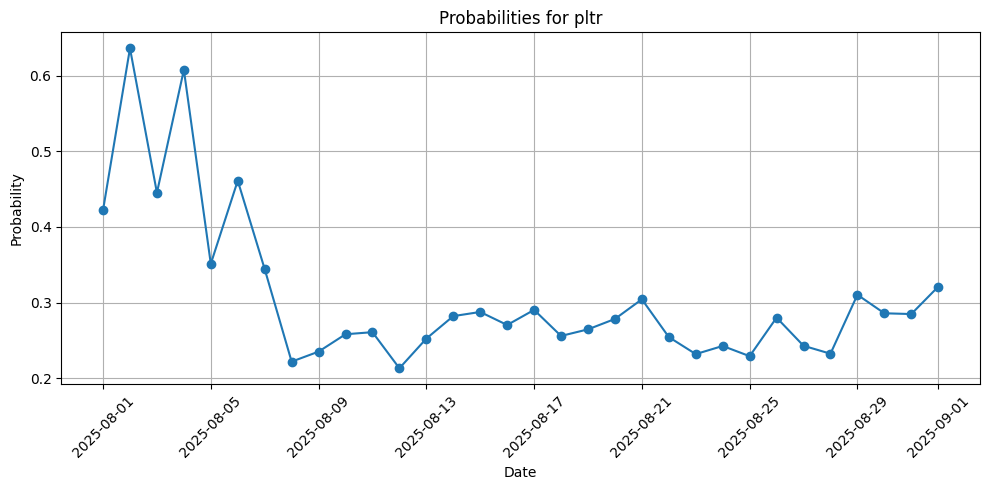

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
stock = input('Enter stock: ')
# Your function should be defined or imported here
# def technical_model(symbol, date):
#     ...

# Initialize variables
start_date = datetime(2025, 8, 1)
end_date = datetime(2025, 9, 1)
current_date = start_date
probabilities = []
dates = []

# Loop through each date
while current_date <= end_date:
    pred, proba = technical_model(stock, current_date.strftime("%Y-%m-%d"))
    probabilities.append(proba)
    dates.append(current_date)
    current_date += timedelta(days=1)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(dates, probabilities, marker='o')
plt.title(f'Probabilities for {stock}')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()